In [ ]:
from rdkit.Chem import rdFingerprintGenerator
from multiprocessing import Pool
from rdkit.Chem import AllChem
from rdkit import Chem
from tqdm import tqdm
import pandas as pd
import numpy as np
import pickle
import gzip
import os

# Load compound info
IKs = open("../processed/enamine_characterization/IKs.txt", "r").readlines()
IKs = [i.strip() for i in IKs]
IK_TO_SMILES = pickle.load(open("../processed/enamine_characterization/IK_TO_SMI.pkl", "rb"))

# Given (NAME, SMILES) create 3D conformer
def generate_3d_conformer(input_list):
    try:
        IK, smi = input_list
        mol = Chem.MolFromSmiles(smi)
        mol = Chem.AddHs(mol)
        params = AllChem.ETKDGv3()
        params.randomSeed = 42 
        AllChem.EmbedMolecule(mol, params=params)
        AllChem.UFFOptimizeMolecule(mol)
        mol.SetProp("_Name", IK)
        return mol
    except:
        return None

# Prepare input list
input_list = [[ik, IK_TO_SMILES[ik]]for ik in IKs]

In [42]:
generate_3d_conformer(input_list[13482])

ValueError: Bad Conformer Id

In [51]:
mol = Chem.MolFromSmiles("CCC1CCCN(CC1)C(=O)[C@@H]2C[C@H]3C[C@H]2C4(C3)NC(=O)NC4=O")
mol = Chem.AddHs(mol)
params = AllChem.ETKDGv3()
params.randomSeed = 42 
AllChem.EmbedMolecule(mol, params=params)

-1

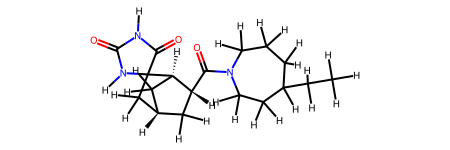

In [52]:
mol

In [ ]:
AllChem.UFFOptimizeMolecule(mol)

In [47]:
input_list[13482]

['DGWYBKHIEYZUIM-AJJWCWOSSA-N',
 'CCC1CCCN(CC1)C(=O)[C@@H]2C[C@H]3C[C@H]2C4(C3)NC(=O)NC4=O |&1:11,13,15,r|']

In [49]:
generate_3d_conformer(["AAAAA", "CCC1CCCN(CC1)C(=O)[C@@H]2C[C@H]3C[C@H]2C4(C3)NC(=O)NC4=O"])

ValueError: Bad Conformer Id

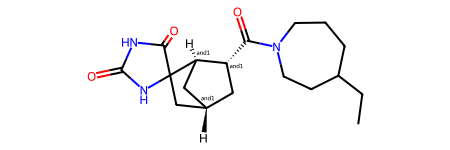

In [45]:
N = 13482
Chem.MolFromSmiles(input_list[N][1])

In [ ]:
# Run conformer generation - parallelized
N_WORKERS = 8
with Pool(N_WORKERS) as pool:
    mols = list(tqdm(pool.imap(generate_3d_conformer, input_list), total=len(input_list)))

# Write results
with gzip.open("../processed/enamine_characterization/conformations.sdf.gz", "wt") as gzfile:
    writer = Chem.SDWriter(gzfile)
    for mol in mols:
        writer.write(mol)
    writer.close()